Create a offset sine wave script using the identity cosAcosB-sinAsinB = cos(A+B). Note here, this does an offset with the center frequency of transmitter. In order for values stay the same, sample rates must match when actually transmitting. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Settings ---
fs = 10_000_000            # 10 MS/s
f_tone = 500_000           # 0.5 MHz tone
duration = 1.0             # 1 second is plenty
out_path = "./waveforms/sine_tone500KHz_at_fs10MHz_1sec.dat"

# Make sure END matches START in phase:
#   duration * f_tone must be an integer
N_cycles = int(duration * f_tone)
duration = N_cycles / f_tone   # adjust duration to be exact

# Time vector
t = np.arange(int(fs * duration)) / fs

# Generate CLEAN complex sinusoid
amp = 0.7                      # avoid clipping, 70% fullscale
iq = amp * np.exp(1j * 2 * np.pi * f_tone * t)

# Convert to int8 interleaved
I = np.int8(np.real(iq) * 127)
Q = np.int8(np.imag(iq) * 127)

iq_bytes = np.empty(2 * len(I), dtype=np.int8)
iq_bytes[0::2] = I
iq_bytes[1::2] = Q

# Save file
iq_bytes.tofile(out_path)
print("Saved clean, continuous tone to:", out_path)

# N = 2000   # number of samples to plot (adjust if needed)

# plt.figure(figsize=(12,4))
# plt.plot(I[:N], label="I (real part)")
# #plt.plot(Q[:N], label="Q (imag part)")
# plt.title("0.5 MHz Clean Complex Tone (First {} Samples)".format(N))
# plt.xlabel("Sample Index")
# plt.ylabel("Amplitude (int8)")
# plt.legend()
# plt.grid(True)
# plt.show()

Saved clean, continuous tone to: ./waveforms/sine_tone500KHz_at_fs10MHz_1sec.dat


Can also create all IQ all 1's

In [3]:
import numpy as np

# --- Settings ---
fs = 5_000_000              # sample rate (Hz)
symbol_rate = 100_000      # symbols per second -> fs/symrate = 50 sps
symbols_high = 100            # I = 32167, Q = 0 - 1ms for 100
symbols_low  = 900            # I = 0, Q = 0
duration = 3               # total output duration (seconds)
out_path = "./waveforms/hi_low_I_5Mhzfs_3sec.dat"


# --- Samples per symbol ---
sps = int(fs / symbol_rate)

# --- Build one pattern block of symbols ---
num_symbols = symbols_high + symbols_low

I_symbols = np.zeros(num_symbols, dtype=np.int8)
Q_symbols = np.zeros(num_symbols, dtype=np.int8)

I_symbols[:symbols_high] = 127   # first 100 symbols high
# Q stays zero

# --- Expand symbols into samples ---
I_block = np.repeat(I_symbols, sps)
Q_block = np.repeat(Q_symbols, sps)

block_len = len(I_block) # block being chuncks [samples high, samples low]

# --- Determine total samples needed ---
total_I_samples = int(fs * duration)

# --- Repeat block until duration is filled ---
repeats = int(np.ceil(total_I_samples / block_len))

I_full = np.tile(I_block, repeats)[:total_I_samples] 
Q_full = np.tile(Q_block, repeats)[:total_I_samples]

# --- Interleave I/Q int8 ---
iq = np.empty(2*total_I_samples, dtype=np.int8)
iq[0::2] = I_full
iq[1::2] = Q_full

# --- Save ---
iq.tofile(out_path)

print("Saved:", out_path)
print("Duration (s):", duration)
print("Total I samples:", total_I_samples)
print("Symbols per block:", num_symbols)
print("Samples per symbol:", sps)


Saved: ./waveforms/hi_low_I_5Mhzfs_3sec.dat
Duration (s): 3
Total I samples: 15000000
Symbols per block: 1000
Samples per symbol: 50


Now, do have the on symbols to rotate through (1,1)(-1,1),(-1,-1),(1,1)

In [4]:
import numpy as np

# --- Settings ---
fs = 5_000_000              # sample rate (Hz)
symbol_rate = 100_000      # symbols per second -> fs/symrate = 50 sps
symbols_high = 100            # Rotate through I,Q values
symbols_low  = 900            # I = 0, Q = 0
duration = 3               # total output duration (seconds)
out_path = "./waveforms/burst_QPSK_5Mhzfs_3sec.dat"


# --- Samples per symbol ---
sps = int(fs / symbol_rate)

# --- Build one pattern block of symbols ---
num_symbols = symbols_high + symbols_low

I_symbols = np.zeros(num_symbols, dtype=np.int8)
Q_symbols = np.zeros(num_symbols, dtype=np.int8)

# Now, instead of just I high and Q low, rotate symbols through
# (1,1), (-1,1), (-1,-1), (1,-1) for a QPSK-like pattern
for i in range(symbols_high):
    idx = i % 4
    if idx == 0:
        I_symbols[i] = 127
        Q_symbols[i] = 127
    elif idx == 1:
        I_symbols[i] = -127
        Q_symbols[i] = 127
    elif idx == 2:
        I_symbols[i] = -127
        Q_symbols[i] = -127
    elif idx == 3:
        I_symbols[i] = 127
        Q_symbols[i] = -127


# --- Expand symbols into samples ---
I_block = np.repeat(I_symbols, sps)
Q_block = np.repeat(Q_symbols, sps)

block_len = len(I_block) # block being chuncks [samples high, samples low]

# --- Determine total samples needed ---
total_I_samples = int(fs * duration)

# --- Repeat block until duration is filled ---
repeats = int(np.ceil(total_I_samples / block_len))

I_full = np.tile(I_block, repeats)[:total_I_samples] 
Q_full = np.tile(Q_block, repeats)[:total_I_samples]

# --- Interleave I/Q int8 ---
iq = np.empty(2*total_I_samples, dtype=np.int8)
iq[0::2] = I_full
iq[1::2] = Q_full

# --- Save ---
iq.tofile(out_path)

print("Saved:", out_path)
print("Duration (s):", duration)
print("Total I samples:", total_I_samples)
print("Symbols per block:", num_symbols)
print("Samples per symbol:", sps)


Saved: ./waveforms/burst_QPSK_5Mhzfs_3sec.dat
Duration (s): 3
Total I samples: 15000000
Symbols per block: 1000
Samples per symbol: 50


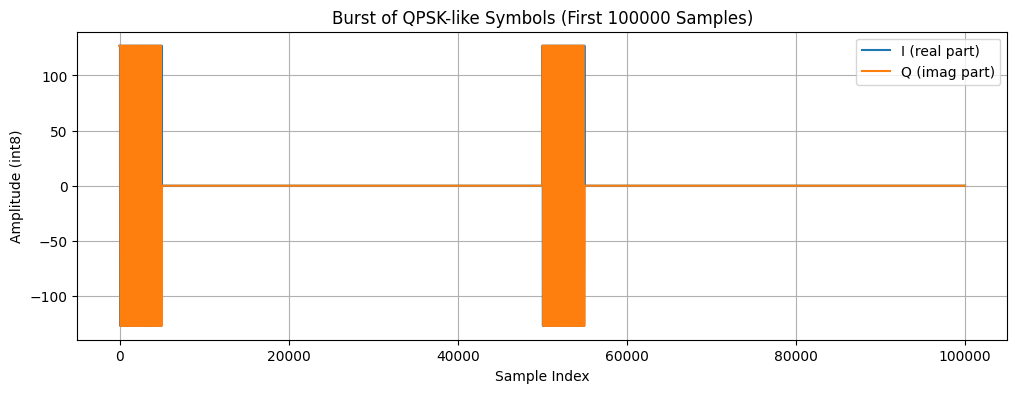

In [5]:
#plot first 1000 samples to verify pattern
import matplotlib.pyplot as plt
N = 100000   # number of samples to plot (adjust if needed)
plt.figure(figsize=(12,4))
plt.plot(I_full[:N], label="I (real part)")
plt.plot(Q_full[:N], label="Q (imag part)")
plt.title("Burst of QPSK-like Symbols (First {} Samples)".format(N))
plt.xlabel("Sample Index")
plt.ylabel("Amplitude (int8)")
plt.legend()
plt.grid(True)
plt.show()

Hello world Message

In [14]:
# convert hello world to binary and then to QPSK symbols interleaved in I/Q

msg = "Hello, World! Testing to see if this really works!"
msg_bytes = msg.encode('ascii')
msg_bits = np.unpackbits(np.frombuffer(msg_bytes, dtype=np.uint8))
print("Symbol length (bits):", len(msg_bits)/2)
print(msg_bits)

Symbol length (bits): 200.0
[0 1 0 0 1 0 0 0 0 1 1 0 0 1 0 1 0 1 1 0 1 1 0 0 0 1 1 0 1 1 0 0 0 1 1 0 1
 1 1 1 0 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 0 0 1 0 0 1 1 0 1 1 0 0 0 1 1 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0
 0 0 1 0 1 0 1 0 0 0 1 1 0 0 1 0 1 0 1 1 1 0 0 1 1 0 1 1 1 0 1 0 0 0 1 1 0
 1 0 0 1 0 1 1 0 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0
 1 1 0 1 1 1 1 0 0 1 0 0 0 0 0 0 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 1 1 0 1 0 0 1 0 1 1 0 0 1 1 0 0 0 1 0 0 0 0 0 0 1 1
 1 0 1 0 0 0 1 1 0 1 0 0 0 0 1 1 0 1 0 0 1 0 1 1 1 0 0 1 1 0 0 1 0 0 0 0 0
 0 1 1 1 0 0 1 0 0 1 1 0 0 1 0 1 0 1 1 0 0 0 0 1 0 1 1 0 1 1 0 0 0 1 1 0 1
 1 0 0 0 1 1 1 1 0 0 1 0 0 1 0 0 0 0 0 0 1 1 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 0 0 1 0 0 1 1 0 1 0 1 1 0 1 1 1 0 0 1 1 0 0 1 0 0 0 0 1]


In [7]:
# function to map bits to QPSK symbols interleaved in I/Q
def bits_to_qpsk_symbols(bits):
    
    I_symbols = []
    Q_symbols = []
    
    for i in range(0, len(bits), 2):
        b1, b2 = bits[i], bits[i+1]
        if (b1, b2) == (1,1):
            I_symbols.append(127)
            Q_symbols.append(127)
        elif (b1, b2) == (0,1):
            I_symbols.append(-127)
            Q_symbols.append(127)
        elif (b1, b2) == (0,0):
            I_symbols.append(-127)
            Q_symbols.append(-127)
        elif (b1, b2) == (1,0):
            I_symbols.append(127)
            Q_symbols.append(-127)
    # interleave I/Q
    iq = np.empty(2*len(I_symbols), dtype=np.int8)
    iq[0::2] = I_symbols
    iq[1::2] = Q_symbols
    return iq

In [ ]:
def bits_to_hamming(msg_bits):
    # Pad bits to multiple of 4
    while len(msg_bits) % 4 != 0:
        msg_bits = np.append(msg_bits, 0)
    
    hamming_code = []
    
    for i in range(0, len(msg_bits), 4):
        d1, d2, d3, d4 = msg_bits[i:i+4]
        
        # Calculate parity bits
        p1 = (d1 + d2 + d4) % 2
        p2 = (d1 + d3 + d4) % 2
        p3 = (d2 + d3 + d4) % 2
        
        # Append data and parity bits in order: p1, p2, d1, p3, d2, d3, d4
        hamming_code.extend([p1, p2, d1, p3, d2, d3, d4])
    
    return np.array(hamming_code, dtype=np.int8)

In [8]:
import numpy as np

# --- Settings ---
fs = 5_000_000              # sample rate (Hz)
symbol_rate = 100_000      # symbols per second -> fs/symrate = 50 sps
symbols_low  = 800            # I = 0, Q = 0
duration = 3               # total output duration (seconds)
out_path = "./waveforms/burst_QPSK_msg_5Mhzfs_3sec.dat"


# --- Samples per symbol ---
sps = int(fs / symbol_rate)

# --- Build one pattern block of symbols ---
pilot_length = 4
msg_iq = bits_to_qpsk_symbols(msg_bits)
msg_len = len(msg_iq) // 2  # number of I/Q symbol pairs

num_symbols = pilot_length + msg_len + symbols_low

I_symbols = np.zeros(num_symbols, dtype=np.int8)
Q_symbols = np.zeros(num_symbols, dtype=np.int8)

# Now, instead of just I high and Q low, rotate symbols through
# (1,1), (-1,1), (-1,-1), (1,-1) for a QPSK-like pattern
for i in range(pilot_length):
    idx = i % 4
    if idx == 0:
        I_symbols[i] = 127
        Q_symbols[i] = 127
    elif idx == 1:
        I_symbols[i] = -127
        Q_symbols[i] = 127
    elif idx == 2:
        I_symbols[i] = -127
        Q_symbols[i] = -127
    elif idx == 3:
        I_symbols[i] = 127
        Q_symbols[i] = -127


# make the following symbols after the pilot be the message symbols
for i in range(pilot_length, pilot_length + msg_len):
    idx = i - pilot_length
    I_symbols[i] = msg_iq[2*idx]
    Q_symbols[i] = msg_iq[2*idx + 1]

# --- Expand symbols into samples ---
I_block = np.repeat(I_symbols, sps)
Q_block = np.repeat(Q_symbols, sps)

block_len = len(I_block) # block being chuncks [samples high, samples low]

# --- Determine total samples needed ---
total_I_samples = int(fs * duration)

# --- Repeat block until duration is filled ---
repeats = int(np.ceil(total_I_samples / block_len))

I_full = np.tile(I_block, repeats)[:total_I_samples] 
Q_full = np.tile(Q_block, repeats)[:total_I_samples]

# --- Interleave I/Q int8 ---
iq = np.empty(2*total_I_samples, dtype=np.int8)
iq[0::2] = I_full
iq[1::2] = Q_full

# --- Save ---
iq.tofile(out_path)

print("Saved:", out_path)
print("Duration (s):", duration)
print("Total I samples:", total_I_samples)
print("Symbols per block:", num_symbols)
print("Samples per symbol:", sps)


Saved: ./waveforms/burst_QPSK_msg_5Mhzfs_3sec.dat
Duration (s): 3
Total I samples: 15000000
Symbols per block: 1004
Samples per symbol: 50


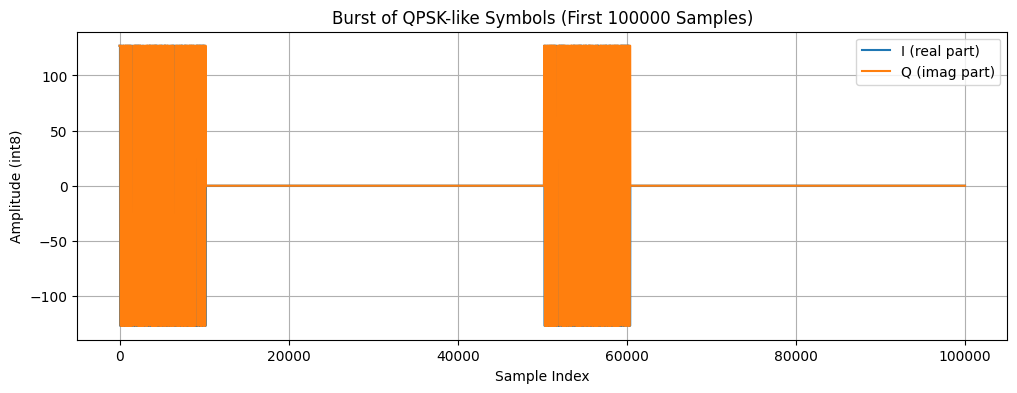

In [13]:
#plot first 1000 samples to verify pattern
import matplotlib.pyplot as plt
N = 100000   # number of samples to plot (adjust if needed)
plt.figure(figsize=(12,4))
plt.plot(I_full[:N], label="I (real part)")
plt.plot(Q_full[:N], label="Q (imag part)")
plt.title("Burst of QPSK-like Symbols (First {} Samples)".format(N))
plt.xlabel("Sample Index")
plt.ylabel("Amplitude (int8)")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
#print first 12 bits of msg
print("First 12 bits of message:")
print(msg_bits[:12])

First 12 bits of message:
[0 1 0 0 1 0 0 0 0 1 1 0]


Elias - with phase offset

In [ ]:
import numpy as np

# --- Settings ---
fs = 5_000_000              # sample rate (Hz)
symbol_rate = 100_000      # symbols per second -> fs/symrate = 50 sps
symbols_high = 100            # I = 32167, Q = 0 - 1ms for 100
symbols_low  = 900            # I = 0, Q = 0
duration = 3               # total output duration (seconds)
out_path = "./waveforms/phase_offset_hi_low_I_5Mhzfs_3sec.dat"

A = 80 # amplitude (keep <127 to avoid clipping after rotation)
phi_deg = 30
phi = np.deg2rad(phi_deg) # set desired constant phase offset here (e.g., 30 degrees)

# --- Samples per symbol ---
sps = int(fs / symbol_rate)

# --- Build one pattern block of symbols ---
num_symbols = symbols_high + symbols_low

I_symbols = np.zeros(num_symbols, dtype=np.int8)
Q_symbols = np.zeros(num_symbols, dtype=np.int8)

I_symbols[:symbols_high] = A   # first 100 symbols high
# Q stays zero

# --- Expand symbols into samples ---
I_block = np.repeat(I_symbols, sps)
Q_block = np.repeat(Q_symbols, sps)

block_len = len(I_block) # block being chuncks [samples high, samples low]

# --- Determine total samples needed ---
total_I_samples = int(fs * duration)

# --- Repeat block until duration is filled ---
repeats = int(np.ceil(total_I_samples / block_len))

I_full = np.tile(I_block, repeats)[:total_I_samples] 
Q_full = np.tile(Q_block, repeats)[:total_I_samples]

# Apply constant phase offset: (I + jQ) * e^(j phi)
x = I_full + 1j * Q_full
x_rot = x * np.exp(1j * phi)

# Quantize back to int8 safely
I_full_q = np.clip(np.round(np.real(x_rot)), -128, 127).astype(np.int8)
Q_full_q = np.clip(np.round(np.imag(x_rot)), -128, 127).astype(np.int8)


# --- Interleave I/Q int8 ---
iq = np.empty(2*total_I_samples, dtype=np.int8)
iq[0::2] = I_full
iq[1::2] = Q_full

# --- Save ---
iq.tofile(out_path)

print("Saved:", out_path)
print("Duration (s):", duration)
print("Total I samples:", total_I_samples)
print("Symbols per block:", num_symbols)
print("Samples per symbol:", sps)
print("Phase offset (degrees):", phi_deg)


Saved: ./waveforms/hi_low_I_5Mhzfs_3sec.dat
Duration (s): 3
Total I samples: 15000000
Symbols per block: 1000
Samples per symbol: 50
Phase offset (degrees): 30
